In [27]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Models
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
# Metrics
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [28]:
df = pd.read_csv("Predictive_final_dataset.csv")
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Region                     100000 non-null  object 
 1   Soil_Type                  100000 non-null  object 
 2   Crop                       100000 non-null  object 
 3   Rainfall_mm                100000 non-null  float64
 4   Temperature_Celsius        100000 non-null  float64
 5   Weather_Condition          100000 non-null  object 
 6   Days_to_Harvest            100000 non-null  int64  
 7   Yield_tons_per_hectare     100000 non-null  float64
 8   Farm_Area(acres)           100000 non-null  float64
 9   Fertilizer_Used(tons)      100000 non-null  float64
 10  Pesticide_Used(kg)         100000 non-null  float64
 11  Water_Usage(cubic meters)  100000 non-null  float64
dtypes: float64(7), int64(1), object(4)
memory usage: 9.2+ MB
None
         Rainfall_mm  Tem

#### Data pre-processing

In [29]:
df = df[df['Yield_tons_per_hectare'] > 0]

Ensure valid target values

In [30]:
# Missing values
print(df.isna().sum())

Region                       0
Soil_Type                    0
Crop                         0
Rainfall_mm                  0
Temperature_Celsius          0
Weather_Condition            0
Days_to_Harvest              0
Yield_tons_per_hectare       0
Farm_Area(acres)             0
Fertilizer_Used(tons)        0
Pesticide_Used(kg)           0
Water_Usage(cubic meters)    0
dtype: int64


No missing values observed -> no imputation required

In [31]:
df['Fertilizer_per_acre'] = df['Fertilizer_Used(tons)'] / df['Farm_Area(acres)']
df['Pesticide_per_acre']  = df['Pesticide_Used(kg)'] / df['Farm_Area(acres)']
df['Water_per_acre']      = df['Water_Usage(cubic meters)'] / df['Farm_Area(acres)']
df['Total_Water_Available'] = df['Rainfall_mm'] + df['Water_Usage(cubic meters)']
df['Moisture_Heat_Index']   = df['Rainfall_mm'] / (df['Temperature_Celsius'] + 1)
df['Growing_Degree_Days'] = (df['Temperature_Celsius'] * df['Days_to_Harvest'])
df['Input_Cost_Index'] = (
    df['Fertilizer_per_acre'] +
    df['Pesticide_per_acre'] +
    df['Water_per_acre']
)

heat_threshold = df['Temperature_Celsius'].quantile(0.75)
df['Heat_Stress_Flag'] = (df['Temperature_Celsius'] > heat_threshold).astype(int)
drought_threshold = df['Rainfall_mm'].quantile(0.50)
df['Drought_Risk_Flag'] = (df['Rainfall_mm'] < drought_threshold).astype(int)
df['Weather_Risk_Score'] = (df['Heat_Stress_Flag'] + df['Drought_Risk_Flag'])

adding domain-driven features to capture input intensity and environmental effects

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99974 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Region                     99974 non-null  object 
 1   Soil_Type                  99974 non-null  object 
 2   Crop                       99974 non-null  object 
 3   Rainfall_mm                99974 non-null  float64
 4   Temperature_Celsius        99974 non-null  float64
 5   Weather_Condition          99974 non-null  object 
 6   Days_to_Harvest            99974 non-null  int64  
 7   Yield_tons_per_hectare     99974 non-null  float64
 8   Farm_Area(acres)           99974 non-null  float64
 9   Fertilizer_Used(tons)      99974 non-null  float64
 10  Pesticide_Used(kg)         99974 non-null  float64
 11  Water_Usage(cubic meters)  99974 non-null  float64
 12  Fertilizer_per_acre        99974 non-null  float64
 13  Pesticide_per_acre         99974 non-null  float64


#### EDA

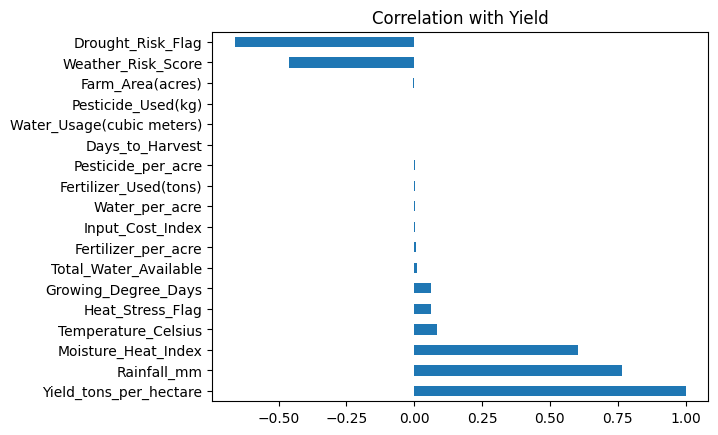

In [33]:
corr = df.select_dtypes(include=['number']).corr()

corr['Yield_tons_per_hectare'].sort_values(ascending=False).plot(kind='barh')
plt.title("Correlation with Yield")
plt.show()

Identify strongest predictors -> guides feature selection

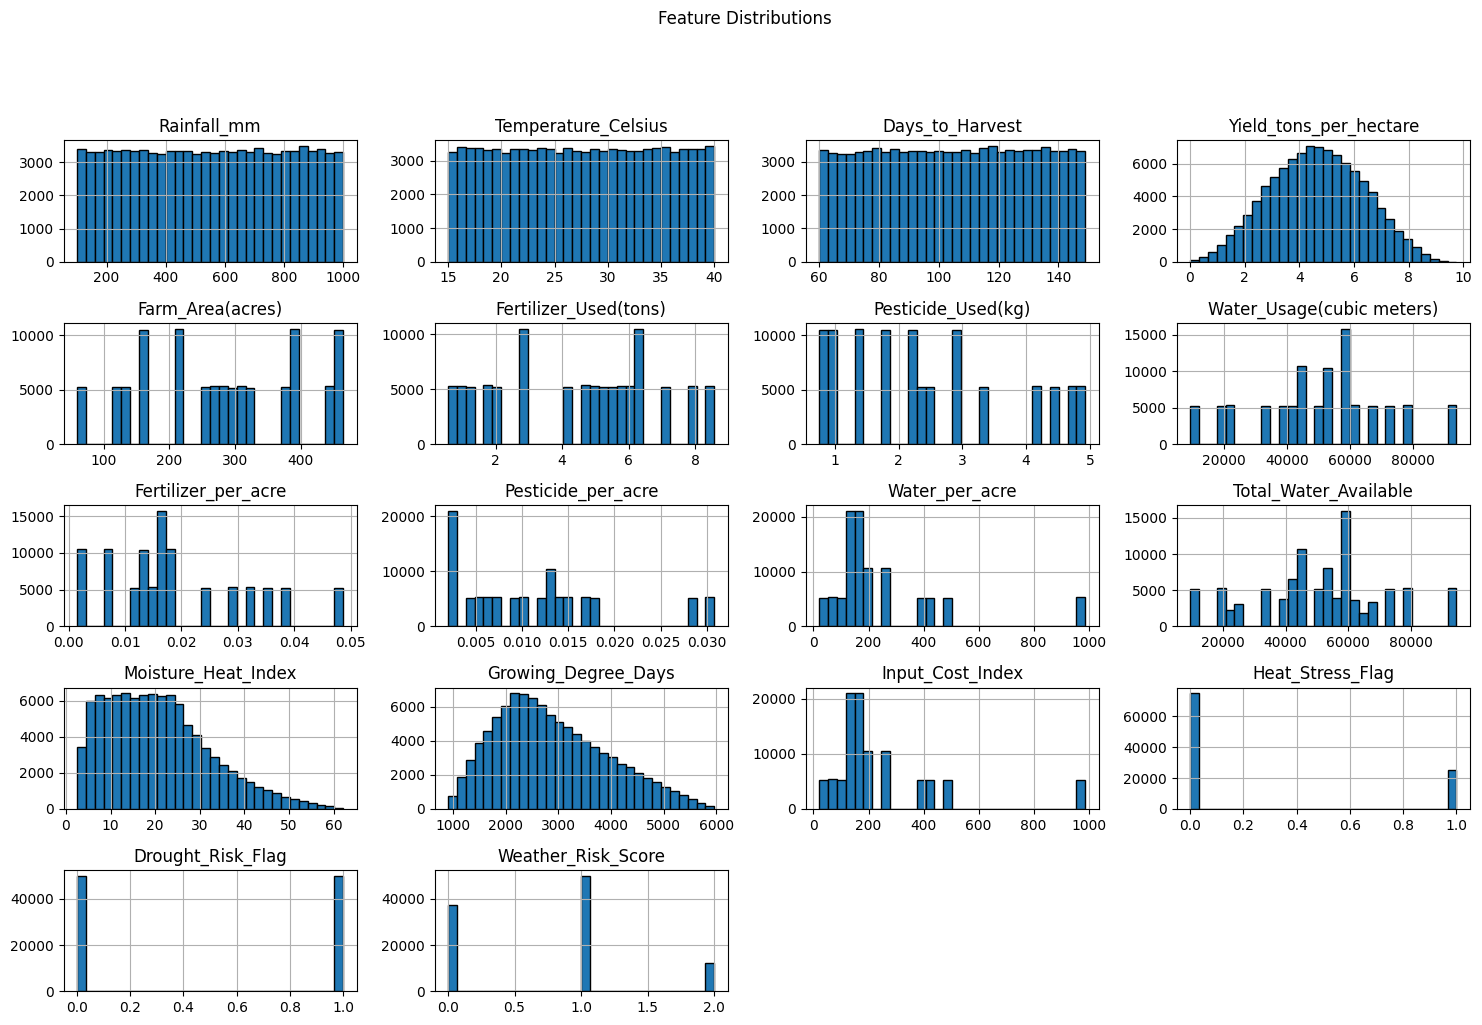

In [34]:
num_cols = df.select_dtypes(include=['number']).columns

df[num_cols].hist(figsize=(15,10), bins=30, edgecolor='black')
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Check spread and skewness -> no major scaling issues observed

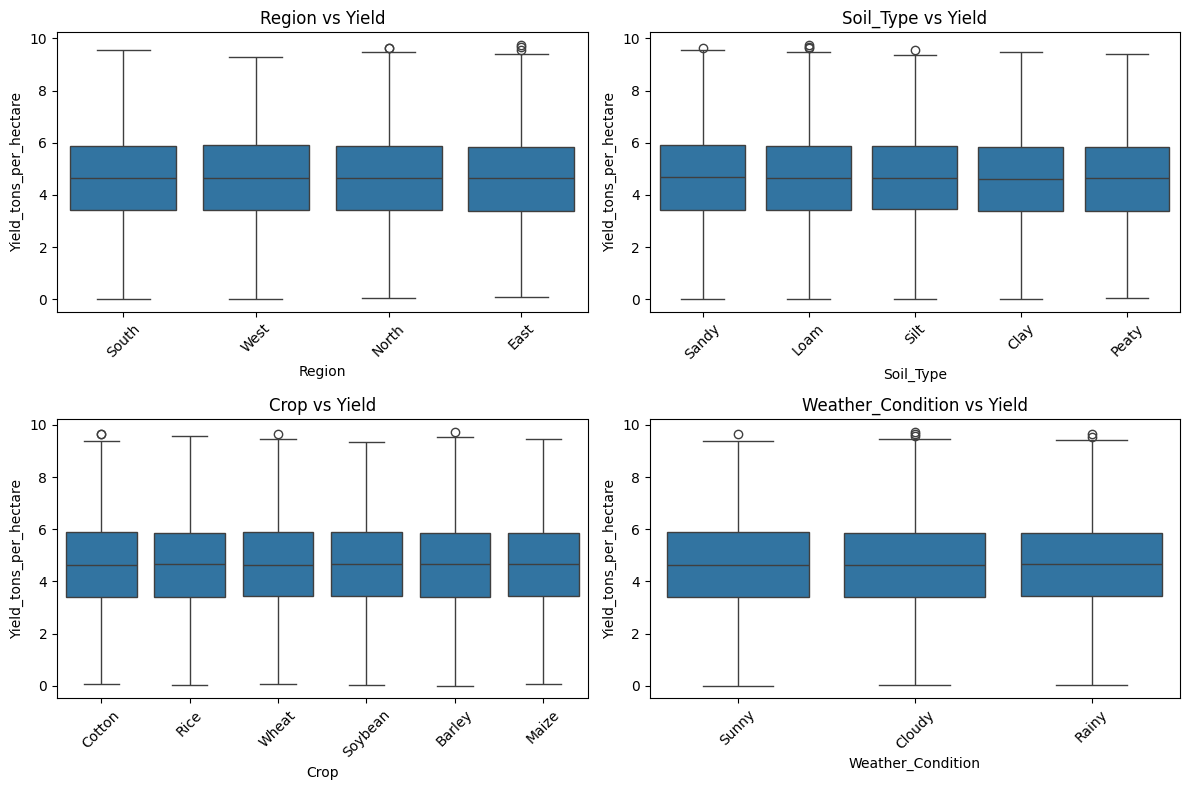

In [35]:
cat_cols = df.select_dtypes(include='object').columns
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()
for i, col in enumerate(cat_cols):
    sns.boxplot(
        x=col,
        y='Yield_tons_per_hectare',
        data=df,
        ax=axs[i]
    )
    axs[i].set_title(f"{col} vs Yield")
    axs[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [36]:
for col in cat_cols:
    groups = [df[df[col] == val]['Yield_tons_per_hectare'] for val in df[col].unique()]
    stat, p = f_oneway(*groups)
    print(f"{col}: p-value = {p}")

Region: p-value = 0.16327961640355002
Soil_Type: p-value = 0.28838276162498877
Crop: p-value = 0.8185022240759203
Weather_Condition: p-value = 0.8475761510707313


p > 0.05 -> categorical variables not statistically significant → excluded from modelling

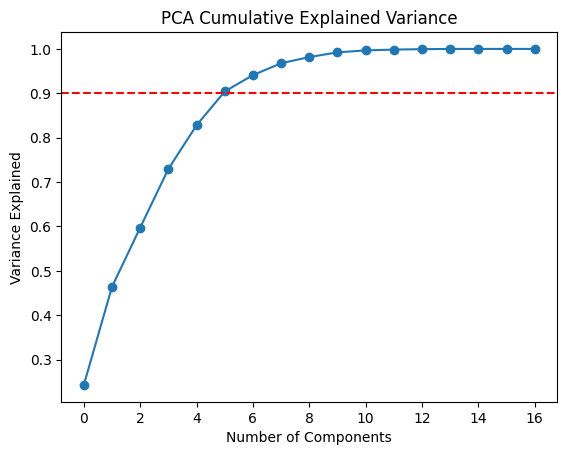

Components for 95% variance: 8


In [37]:
X = df.select_dtypes(include=['number']).drop(columns=['Yield_tons_per_hectare'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.plot(cum_var, marker='o')
plt.axhline(0.90, linestyle='--', color='red')
plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Variance Explained")
plt.show()

print("Components for 95% variance:", np.argmax(cum_var >= 0.95) + 1)

PCA -> Reduce multicollinearity and identify latent structure in features.

~95% variance explained → limited components capture most information

In [38]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(X.columns))],
    index=X.columns
)

for pc in ['PC1', 'PC2', 'PC3']:
    print("\n", pc, "Top Drivers:")

    top_features = loadings[pc].abs().sort_values(ascending=False).head(3)

    for feat in top_features.index:
        sign = "+" if loadings[pc][feat] > 0 else "-"
        print(f"{sign}{loadings[pc][feat]:.3f}  {feat}")


 PC1 Top Drivers:
+0.469  Input_Cost_Index
+0.469  Water_per_acre
+0.442  Pesticide_per_acre

 PC2 Top Drivers:
+0.480  Weather_Risk_Score
--0.464  Moisture_Heat_Index
--0.372  Rainfall_mm

 PC3 Top Drivers:
+0.482  Growing_Degree_Days
+0.421  Temperature_Celsius
+0.411  Rainfall_mm


PC1 -> farm input intensity (fertilizer, pesticide, water usage).

PC2 -> weather and climate stress (rainfall, heat, drought conditions).

PC3 -> crop growth conditions (temperature and growing degree days).

PCA used to identify the most influential features; original features retained for modelling to preserve interpretability.

#### Feature selection and modelling
Use all features and then selected features based on correlation + PCA importance (EDA-informed selection)

In [39]:
X_all = df.select_dtypes(include=['number']).drop(columns=['Yield_tons_per_hectare'])
y_all = df['Yield_tons_per_hectare']

scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all)

selected_features = [
    'Input_Cost_Index',
    'Water_per_acre',
    'Pesticide_per_acre',
    'Weather_Risk_Score',
    'Moisture_Heat_Index',
    'Rainfall_mm',
    'Growing_Degree_Days',
    'Temperature_Celsius'
]
X_eda = df[selected_features]
y_eda = df['Yield_tons_per_hectare']
scaler_eda = StandardScaler()
X_eda_scaled = scaler_eda.fit_transform(X_eda)

60:40 split → ensures fair evaluation and sufficient training data

In [ ]:
#all numerical features
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all_scaled, y_all,
    test_size=0.4,
    random_state=42
)

#eda features
X_train_eda, X_test_eda, y_train_eda, y_test_eda = train_test_split(
    X_eda_scaled, y_eda,
    test_size=0.4,
    random_state=42
)

#### Baseline model using all features for comparison

Random Forest -> captures non-linear relationships and interactions without strong assumptions



In [41]:
rf_all = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    min_samples_split=10,
    min_samples_leaf=1,
    max_depth=10,
    max_features='log2',
    n_jobs=-1
)

rf_all.fit(X_train_all, y_train_all)

y_pred_rf_all = rf_all.predict(X_test_all)

print("RANDOM FOREST BASELINE - numerical features only")
print("R2 Score:", round(r2_score(y_test_all, y_pred_rf_all), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_all, y_pred_rf_all)), 3))
print("MAE:", round(mean_absolute_error(y_test_all, y_pred_rf_all), 3))

RANDOM FOREST BASELINE - numerical features only
R2 Score: 0.585
RMSE: 1.088
MAE: 0.89


Benchmark performance(R2 Score: 0.585) → used to evaluate impact of feature selection

In [42]:

cv_scores_all = cross_val_score(
    rf_all,
    X_train_all,
    y_train_all,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

cv_scores_all_rounded = np.round(cv_scores_all, 3)

print("Cross-validation R2 Scores:", cv_scores_all_rounded)
print("Mean CV R2 Score:", round(cv_scores_all.mean(), 3))

Cross-validation R2 Scores: [0.59  0.591 0.589]
Mean CV R2 Score: 0.59


Small gap between CV and test → strong generalization, low overfitting

#### Model using EDA-selected features → reduced complexity

In [43]:
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    min_samples_split=10,
    min_samples_leaf=1,
    max_depth=10,
    max_features='log2',
    n_jobs=-1
)

rf.fit(X_train_eda, y_train_eda)

y_pred_rf = rf.predict(X_test_eda)

print("RANDOM FOREST- EDA-selected features")
print("R2 Score:", round(r2_score(y_test_eda, y_pred_rf), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_eda, y_pred_rf)), 3))
print("MAE:", round(mean_absolute_error(y_test_eda, y_pred_rf), 3))

RANDOM FOREST- EDA-selected features
R2 Score: 0.586
RMSE: 1.087
MAE: 0.889


Similar performance (R2 Score: 0.586) -> redundant features removed without accuracy loss

In [ ]:
cv_scores = cross_val_score(
    rf,
    X_train_eda,
    y_train_eda,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

cv_scores_rounded = np.round(cv_scores, 3)

print("Cross-validation R2 Scores:", cv_scores_rounded)
print("Mean CV R2 Score:", round(cv_scores.mean(), 3))

Cross-validation R2 Scores: [0.592 0.592 0.59 ]
Mean CV R2 Score: 0.591


Small gap between CV and test → strong generalization, low overfitting

#### Deep Neural Network model

Autoencoder -> learns non-linear feature compression beyond PCA’s linear limitations
Using EDA-selected features ensures the autoencoder learns from the most relevant variables, improving representation quality

In [ ]:
input_dim = X_train_eda.shape[1]
encoding_dim = 6  
input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(encoding_dim, activation='relu')(encoded)

decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(input_dim, activation='linear')(decoded)
autoencoder = Model(inputs=input_layer, outputs=decoded)# Autoencoder model
autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,598 (76.55 KB)

 Trainable params: 19,598 (76.55 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop_ae = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
history_ae = autoencoder.fit(
    X_train_eda, X_train_eda,   
    validation_split=0.2,
    epochs=100,
    batch_size=1024,
    callbacks=[early_stop_ae],
    verbose=1
)

Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.7426 - val_loss: 0.1483
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1081 - val_loss: 0.0440
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0367 - val_loss: 0.0269
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0260 - val_loss: 0.0236
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0231 - val_loss: 0.0216
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0212 - val_loss: 0.0204
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0199 - val_loss: 0.0198
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0187 - val_loss: 0.0170
Epoch 9/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0162 - val_loss: 0.0148
Epoch 10/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0140 - val_loss: 0.0118
Epoch 11/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0110 - val_loss: 0.0100
Epoch 12/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0

In [47]:
encoder = Model(inputs=input_layer, outputs=encoded)

X_train_encoded = encoder.predict(X_train_eda)
X_test_encoded  = encoder.predict(X_test_eda)

print("Original shape:", X_train_eda.shape)
print("Encoded shape:", X_train_encoded.shape)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 489us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 479us/step
Original shape: (59984, 8)
Encoded shape: (59984, 6)


In [48]:
tf.keras.backend.clear_session()

def build_ann(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),

        Dense(128),
        LeakyReLU(alpha=0.1),
        BatchNormalization(), Dropout(0.3),

        Dense(64),
        LeakyReLU(alpha=0.1),
        BatchNormalization(), Dropout(0.2),

        Dense(32),
        LeakyReLU(alpha=0.1),
        
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

ann_model = build_ann(input_dim=X_train_encoded.shape[1])
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [49]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6
)

history = ann_model.fit(
    X_train_encoded, y_train_eda,
    validation_split=0.2,
    epochs=150,
    batch_size=1024,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 10.5756 - mae: 2.7287 - val_loss: 8.5186 - val_mae: 2.6268 - learning_rate: 0.0010
Epoch 2/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0653 - mae: 1.1570 - val_loss: 5.6196 - val_mae: 2.0368 - learning_rate: 0.0010
Epoch 3/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6983 - mae: 1.0526 - val_loss: 3.2976 - val_mae: 1.4941 - learning_rate: 0.0010
Epoch 4/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6165 - mae: 1.0284 - val_loss: 2.2085 - val_mae: 1.2061 - learning_rate: 0.0010
Epoch 5/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.5260 - mae: 1.0024 - val_loss: 1.6460 - val_mae: 1.0447 - learning_rate: 0.0010
Epoch 6/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5156 - mae: 0.9990 - val_loss: 1.4096 - val_mae: 0.9697 - learning_rate: 0.0010
Epoch 7/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.5001 - mae: 0.9956 - val_loss: 1.2972 - val_mae: 0.9317 - learning_rate: 0.0010
Epoch 8/150

In [50]:
y_pred_ann = ann_model.predict(X_test_encoded).flatten()

rmse_ann = np.sqrt(mean_squared_error(y_test_eda, y_pred_ann))
mae_ann  = mean_absolute_error(y_test_eda, y_pred_ann)
r2_ann   = r2_score(y_test_eda, y_pred_ann)

print(f"Autoencoder DNN — R²: {r2_ann:.3f} | RMSE: {rmse_ann:.3f} | MAE: {mae_ann:.3f}")

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 621us/step
Autoencoder DNN — R²: 0.583 | RMSE: 1.091 | MAE: 0.893


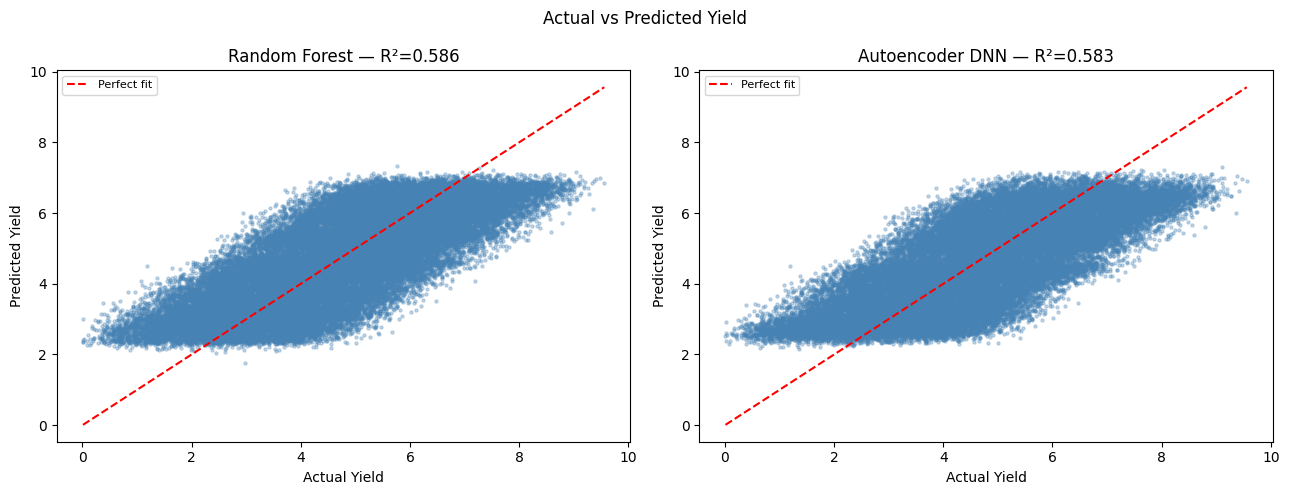

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models = [
    (y_pred_rf, "Random Forest"),
    (y_pred_ann, "Autoencoder DNN")
]

for ax, (y_pred, title) in zip(axes, models):

    ax.scatter(
        y_test_eda,
        y_pred,
        alpha=0.3,
        s=5,
        color='steelblue'
    )

    ax.plot(
        [y_test_eda.min(), y_test_eda.max()],
        [y_test_eda.min(), y_test_eda.max()],
        'r--', lw=1.5, label='Perfect fit'
    )

    ax.set_xlabel('Actual Yield')
    ax.set_ylabel('Predicted Yield')

    ax.set_title(f'{title} — R²={r2_score(y_test_eda, y_pred):.3f}')

    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted Yield')
plt.tight_layout()
plt.show()

The Autoencoder+DNN achieved a comparable R² score of 0.58, suggesting that both models capture similar underlying patterns in the dataset.

The comparable performance of Random Forest and DNN models reinforces that increasing model complexity does not significantly improve results when feature informativeness is limited.